In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
%matplotlib inline

In [16]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2,)

In [17]:
x

array([[ 6.8953457 , -7.29076953],
       [ 6.29929138, -7.18286311],
       [ 7.49793773, -5.57835896],
       ...,
       [ 6.69581601, -8.21847061],
       [ 7.1747585 , -5.11658786],
       [ 6.23382732, -6.14778802]], shape=(1000, 2))

In [18]:
y

array([1, 1, 1, 2, 2, 0, 0, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 1, 1, 0, 0, 0,
       0, 0, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1, 1, 0, 1, 1, 0, 2, 0, 1, 0, 2,
       1, 2, 0, 1, 2, 2, 1, 1, 2, 0, 0, 1, 0, 2, 1, 1, 0, 2, 0, 2, 0, 1,
       0, 1, 1, 1, 0, 1, 2, 1, 0, 2, 0, 1, 2, 2, 2, 2, 0, 1, 0, 0, 2, 0,
       1, 1, 1, 0, 2, 1, 0, 1, 0, 2, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 2, 0, 0, 1, 0, 0, 0, 0, 2, 0, 1, 0, 2, 1, 1, 1, 0, 0, 2,
       2, 1, 1, 1, 2, 0, 2, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 2,
       0, 2, 0, 2, 0, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 2, 0, 1, 2, 0, 1,
       1, 2, 1, 2, 1, 0, 2, 1, 0, 1, 2, 2, 2, 2, 0, 0, 1, 0, 1, 0, 0, 2,
       0, 2, 1, 0, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 2, 2, 0, 0, 1, 2, 0, 0,
       2, 0, 0, 1, 2, 1, 2, 1, 1, 0, 0, 1, 2, 2, 0, 0, 0, 1, 0, 0, 0, 2,
       0, 1, 1, 0, 0, 0, 2, 0, 2, 2, 1, 2, 1, 0, 0, 1, 2, 0, 0, 2, 1, 2,
       1, 1, 1, 2, 2, 2, 1, 0, 1, 0, 0, 2, 0, 1, 2, 2, 0, 0, 1, 0, 2, 2,
       2, 1, 1, 1, 1, 1, 2, 0, 2, 1, 2, 1, 2, 1, 0,

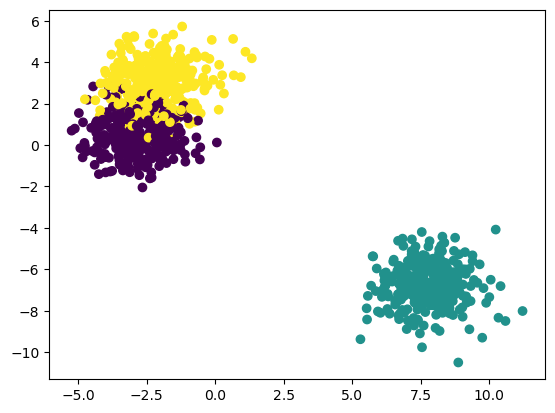

In [19]:
plt.scatter(x[:,0],x[:,1],c=y)

In [20]:
##Standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [24]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(700, 2)
(700,)
(300, 2)
(300,)


In [27]:
#train_test_split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [28]:
print(x_train.shape)
print(x_test.shape)

(700, 2)
(300, 2)


In [30]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [32]:
from sklearn.cluster import KMeans

In [34]:
#elbow method for selecting k-value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

In [35]:
wcss

[1400.0,
 107.19460447056792,
 57.70673814573596,
 48.31670907293609,
 40.06938067563777,
 40.02635633968392,
 31.01294310612003,
 27.93783588582021,
 25.567146259898426,
 23.475087092505902]

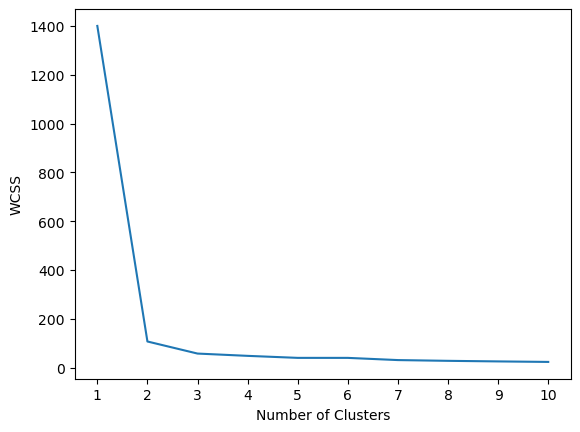

In [36]:
#plot elboe curve 
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [37]:
  kmeans=KMeans(n_clusters=k,init="k-means++")

In [38]:
kmeans.fit_predict(x_train_scaled)

C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


array([1, 9, 7, 4, 1, 2, 3, 8, 8, 8, 9, 2, 3, 5, 8, 9, 7, 7, 1, 1, 6, 4,
       8, 1, 6, 3, 0, 0, 6, 7, 5, 2, 3, 0, 4, 9, 7, 5, 5, 9, 6, 4, 0, 3,
       5, 9, 2, 1, 9, 8, 2, 1, 4, 4, 7, 3, 2, 1, 1, 5, 6, 3, 7, 4, 4, 8,
       9, 2, 4, 8, 8, 9, 5, 3, 8, 9, 8, 7, 1, 3, 1, 2, 2, 1, 3, 7, 1, 6,
       2, 2, 4, 9, 7, 2, 2, 2, 2, 2, 7, 4, 8, 8, 2, 1, 0, 4, 9, 8, 9, 5,
       2, 0, 3, 7, 2, 5, 0, 0, 1, 5, 7, 9, 2, 0, 0, 7, 4, 8, 8, 7, 8, 7,
       0, 4, 6, 3, 3, 2, 8, 3, 9, 6, 4, 4, 2, 1, 8, 0, 2, 0, 2, 9, 5, 7,
       3, 2, 3, 4, 8, 8, 1, 3, 5, 4, 9, 9, 2, 8, 2, 8, 2, 1, 5, 7, 5, 7,
       1, 7, 8, 2, 1, 2, 5, 2, 8, 3, 2, 2, 9, 2, 4, 2, 2, 4, 8, 9, 9, 2,
       1, 9, 3, 6, 0, 7, 1, 3, 5, 7, 2, 2, 9, 9, 5, 5, 4, 9, 5, 8, 0, 2,
       8, 4, 6, 3, 9, 2, 9, 5, 7, 4, 3, 0, 4, 3, 7, 6, 5, 3, 1, 4, 5, 1,
       2, 4, 2, 8, 0, 3, 6, 7, 4, 8, 3, 1, 5, 6, 4, 3, 5, 8, 1, 9, 7, 3,
       8, 5, 5, 9, 3, 1, 7, 2, 2, 9, 6, 1, 8, 2, 9, 3, 9, 2, 7, 0, 8, 8,
       7, 6, 2, 4, 1, 1, 3, 7, 7, 2, 9, 1, 0, 2, 7,

In [39]:
y_pred=kmeans.predict(x_test_scaled)

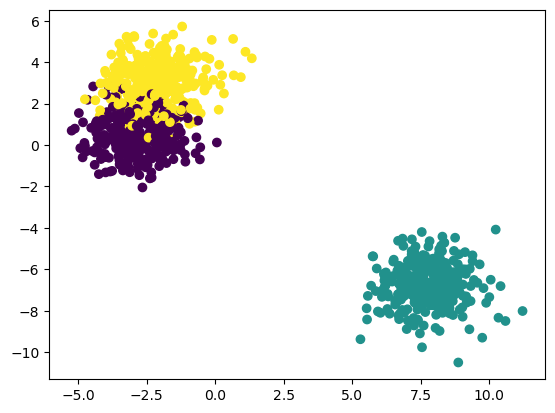

In [40]:
plt.scatter(x[:,0],x[::,1],c=y)

In [ ]:
##validating the k value using:
## ->kneelocator
## ->Silhoutee scoring

In [42]:
##knee locator
!pip install kneed

In [44]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [45]:
kl.elbow

np.int64(2)

In [46]:
##silhoutte score
from sklearn.metrics import silhouette_score

In [50]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train_scaled)
    score=silhouette_score(x_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Sashank\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak o

In [52]:
silhouette_coefficients

[0.8337152657078841,
 0.608792339712102,
 0.5321444621246253,
 0.35928912994650675,
 0.35309969371213384,
 0.3399814576679171,
 0.32994979240925976,
 0.34550601288873584,
 0.31962871154588607]

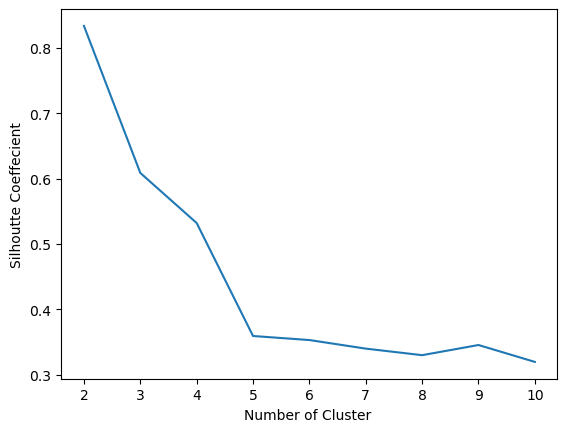

In [54]:
#plot elboe curve 
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluster ")
plt.ylabel("Silhoutte Coeffecient")
plt.show()